# Notebook 02

# Extração de Características utilizando Amino Acid Composition (AAC)

No Notebook 01 foi realizada a Análise Exploratória de Dados (EDA), permitindo compreender a estrutura da base SAGAPEP e identificar as principais características da variável resposta.

Entretanto, ainda existe um problema fundamental: os algoritmos clássicos de Aprendizado de Máquina não conseguem utilizar diretamente sequências de aminoácidos representadas como texto.

Por exemplo, considere a sequência:

```
PKVKMALRTSGHL
```

Embora essa sequência possua significado biológico, ela não pode ser utilizada diretamente por algoritmos como Random Forest, Support Vector Regression ou Redes Neurais.

É necessário transformar cada sequência em um vetor numérico de características (feature vector).

Esse processo é denominado **engenharia de atributos (Feature Engineering)**.

Neste notebook será implementado o primeiro descritor utilizado pelo SAGAPEP: **AAC (Amino Acid Composition)**.

## Objetivos

Ao final deste notebook será possível:

- compreender o conceito de representação de proteínas;
- entender o descritor AAC;
- implementar o algoritmo manualmente;
- gerar um vetor numérico para cada peptídeo;
- construir o primeiro conjunto de dados utilizado pelos modelos de Aprendizado de Máquina.

## O problema da representação

Considere os seguintes peptídeos:

```
PKVKMALRTSGHL

AAAAAAA

GGGGGGG
```

Para um pesquisador, essas sequências possuem significado biológico.

Entretanto, para um algoritmo de Aprendizado de Máquina elas são apenas cadeias de caracteres.

Modelos supervisionados trabalham exclusivamente com vetores numéricos.

Assim, antes de construir qualquer modelo preditivo é necessário transformar cada sequência em uma representação matemática.

Essa etapa recebe o nome de **Extração de Características (Feature Extraction)**.

## Amino Acid Composition (AAC)

O descritor AAC representa cada peptídeo pela frequência relativa dos vinte aminoácidos naturais.

Ao invés de armazenar a ordem dos resíduos, o AAC considera apenas sua composição.

Assim, cada sequência passa a ser representada por um vetor de dimensão fixa igual a vinte.

Por exemplo,

```
AGGA
```

possui

|Aminoácido|Frequência|
|-----------|---------:|
|A|2|
|G|2|

Todos os demais aminoácidos possuem frequência zero.

## Formulação Matemática

Considere uma sequência composta por N aminoácidos.

A frequência relativa do aminoácido i é definida por

AACi​=ni/N​​


onde

- N representa o comprimento da sequência;

- n_i representa o número de ocorrências do aminoácido i.

Dessa forma,

```

AAC_A

AAC_C

AAC_D

...

AAC_Y

```

formam um vetor de dimensão vinte.

A soma de todas as frequências é sempre igual a 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
df = pd.read_csv("../data/raw/sagapep.csv")
df.head(10)

,peptide_fasta_sequence,best_docking_score
0,RFGYGYGPY,-230.308
1,PAAAPPTLPPYFMKGSIIQLANGELKKV,-227.293
2,SIPPCPQTWRSLWIGYSFLMHTG,-224.630
3,RIGRFGYGYGPY,-218.979
4,PGPRYQPFRLT,-218.227
5,WAFTPLHEAAQKGRTQLCALLL,-214.970
6,PGPSSPYIPSPGGAMSPSYSPTSPAYEP,-210.899
7,SRGPPPRATRLPPPGPLCSSFSTP,-210.009
8,GRFGYGYGPY,-209.840
9,PRGPAGPSGPAGKDGRTGHPGTVGPAGIRGPQGHQGPAGPPGPPGP,-209.592


## Os vinte aminoácidos naturais

O descritor AAC utiliza sempre a mesma ordem para construir os vetores.

Essa ordem deve permanecer fixa durante todo o projeto para garantir consistência entre treinamento e predição.

In [3]:
AA = [
    "A","C","D","E","F",
    "G","H","I","K","L",
    "M","N","P","Q","R",
    "S","T","V","W","Y"
]

AA

['A',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'K',
 'L',
 'M',
 'N',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'V',
 'W',
 'Y']

In [4]:
def aac(sequence):
    """
    Calcula o descritor AAC de uma sequência.

    Parameters
    ----------
    sequence : str

    Returns
    -------
    dict
    """

    seq = sequence.upper()

    total = len(seq)

    counts = Counter(seq)

    vector = {}

    for aa in AA:

        vector[aa] = counts.get(aa,0)/total

    return vector

In [5]:
teste = "AGGA"

aac(teste)

{'A': 0.5,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'F': 0.0,
 'G': 0.5,
 'H': 0.0,
 'I': 0.0,
 'K': 0.0,
 'L': 0.0,
 'M': 0.0,
 'N': 0.0,
 'P': 0.0,
 'Q': 0.0,
 'R': 0.0,
 'S': 0.0,
 'T': 0.0,
 'V': 0.0,
 'W': 0.0,
 'Y': 0.0}

In [6]:
aac_df = (
    df["peptide_fasta_sequence"]
    .apply(aac)
    .apply(pd.Series)
)

aac_df.head()

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
0,0.000000,0.000000,0.0,0.000000,0.111111,0.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.111111,0.000000,0.111111,0.000000,0.000000,0.000000,0.000000,0.333333
1,0.142857,0.000000,0.0,0.035714,0.035714,0.071429,0.000000,0.071429,0.107143,0.107143,0.035714,0.035714,0.178571,0.035714,0.000000,0.035714,0.035714,0.035714,0.000000,0.035714
2,0.000000,0.043478,0.0,0.000000,0.043478,0.086957,0.043478,0.086957,0.000000,0.086957,0.043478,0.000000,0.130435,0.043478,0.043478,0.130435,0.086957,0.000000,0.086957,0.043478
3,0.000000,0.000000,0.0,0.000000,0.083333,0.333333,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,0.083333,0.000000,0.166667,0.000000,0.000000,0.000000,0.000000,0.250000
4,0.000000,0.000000,0.0,0.000000,0.090909,0.090909,0.000000,0.000000,0.000000,0.090909,0.000000,0.000000,0.272727,0.090909,0.181818,0.000000,0.090909,0.000000,0.000000,0.090909


In [7]:
aac_df["best_docking_score"] = df["best_docking_score"]

In [8]:
aac_df.shape

(296, 21)

## Validação da matriz AAC

Cada linha da matriz AAC representa um peptídeo.

Cada coluna representa a frequência relativa de um dos vinte aminoácidos naturais.

Uma propriedade importante do descritor AAC é que a soma das frequências deve ser exatamente igual a 1 para todas as sequências.

Essa propriedade será verificada antes das análises seguintes.

In [9]:
# ============================================================
# Verificando se todas as linhas somam 1
# ============================================================

aac_only = aac_df.drop(columns=["best_docking_score"])

soma = aac_only.sum(axis=1)

print("Valor mínimo :", soma.min())
print("Valor máximo :", soma.max())

assert np.allclose(soma,1)

print("\n✓ Todas as sequências foram codificadas corretamente.")

Valor mínimo : 0.9999999999999998
Valor máximo : 1.0000000000000002

✓ Todas as sequências foram codificadas corretamente.


In [10]:
# ============================================================
# Estatísticas descritivas
# ============================================================

estatisticas = aac_only.describe().T
estatisticas["variance"] = aac_only.var()

# quais aminoácidos apresentam maior variabilidade na base?
estatisticas.sort_values(
    by="std",
    ascending=False
)

,count,mean,std,min,25%,50%,75%,max,variance
P,296.0,0.206402,0.195491,0.0,0.071429,0.153846,0.273990,0.916667,0.038217
G,296.0,0.118448,0.114252,0.0,0.000000,0.090909,0.182660,0.700000,0.013054
S,296.0,0.086249,0.083495,0.0,0.000000,0.076923,0.125000,0.363636,0.006971
L,296.0,0.061796,0.073726,0.0,0.000000,0.045455,0.100000,0.454545,0.005436
A,296.0,0.068262,0.073571,0.0,0.000000,0.058824,0.106725,0.424242,0.005413
E,296.0,0.040293,0.061075,0.0,0.000000,0.000000,0.076923,0.333333,0.003730
V,296.0,0.045059,0.060556,0.0,0.000000,0.000000,0.083333,0.300000,0.003667
Q,296.0,0.037503,0.059861,0.0,0.000000,0.000000,0.067857,0.454545,0.003583
K,296.0,0.043845,0.059576,0.0,0.000000,0.000000,0.083333,0.250000,0.003549
T,296.0,0.043210,0.057291,0.0,0.000000,0.000000,0.083333,0.312500,0.003282


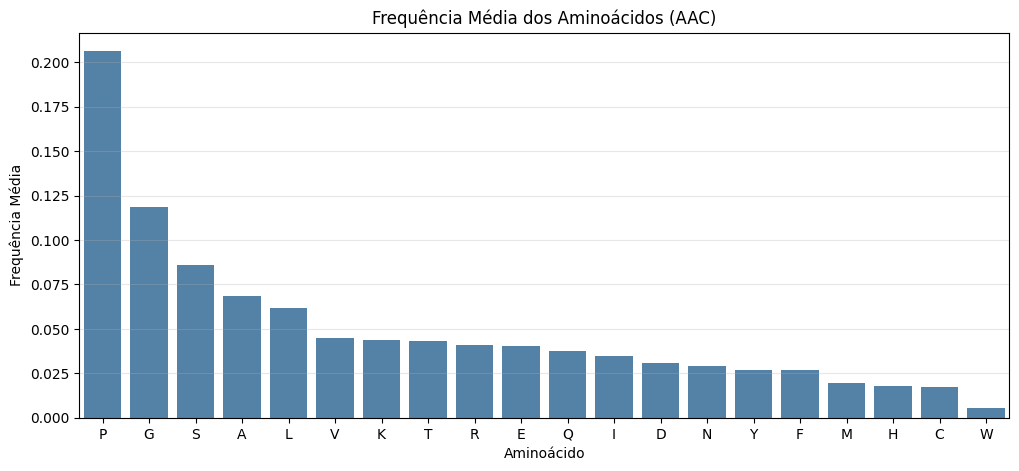

In [11]:
# ============================================================
# Frequência média dos aminoácidos
# ============================================================

media = (
    aac_only
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

sns.barplot(
    x=media.index,
    y=media.values,
    color="steelblue"
)

plt.title("Frequência Média dos Aminoácidos (AAC)")

plt.xlabel("Aminoácido")

plt.ylabel("Frequência Média")

plt.grid(axis="y", alpha=0.3)

plt.show()

A Figura apresenta a frequência média de cada aminoácido após a codificação AAC. Observa-se predominância de prolina (P) e glicina (G), resultado consistente com a caracterização realizada durante a análise exploratória da base.

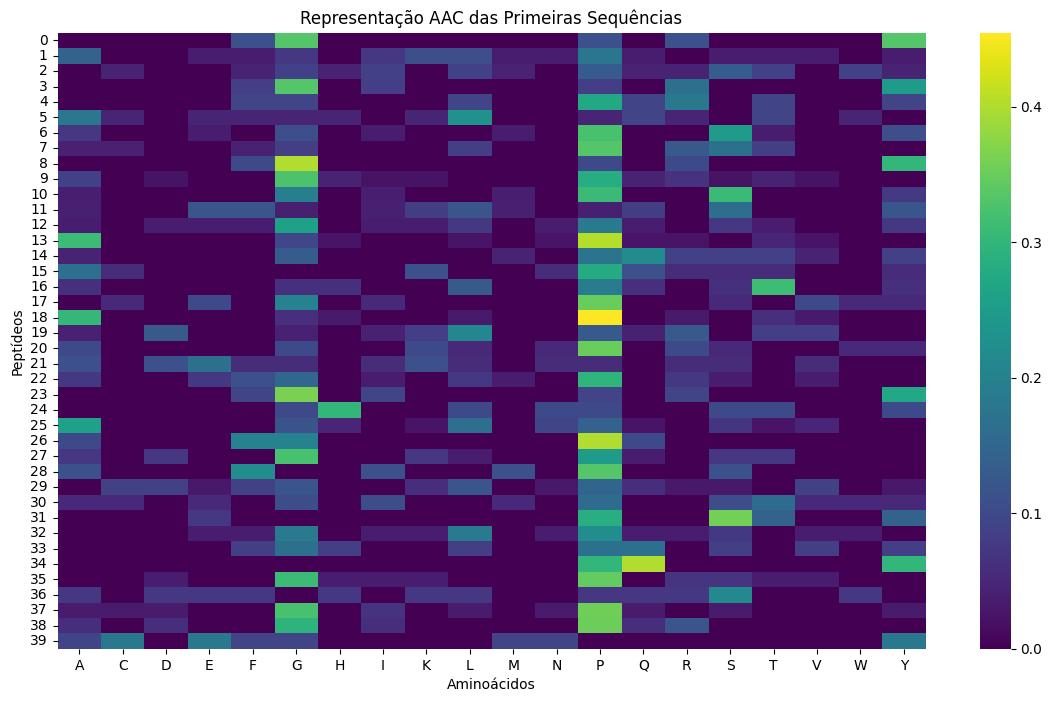

In [12]:
# ============================================================
# Heatmap das primeiras sequências
# ============================================================

plt.figure(figsize=(14,8))

sns.heatmap(
    aac_only.iloc[:40],
    cmap="viridis"
)

plt.title("Representação AAC das Primeiras Sequências")

plt.xlabel("Aminoácidos")

plt.ylabel("Peptídeos")

plt.show()

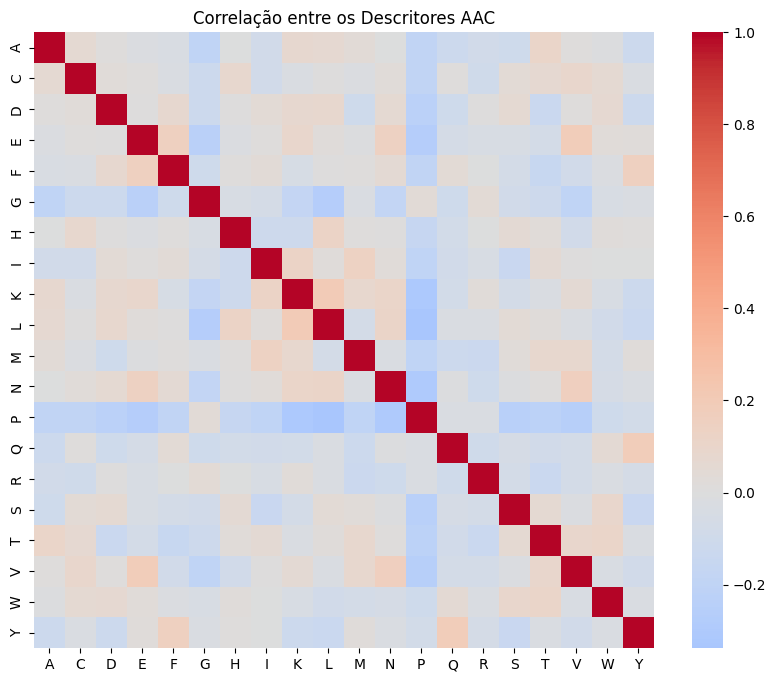

In [13]:
# Correlação entre descritores AAC
corr = aac_only.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlação entre os Descritores AAC")

plt.show()

In [14]:
#Correlações mais fortes
corr_abs = corr.abs()

mask = np.triu(np.ones_like(corr_abs,dtype=bool))

corr_upper = corr_abs.mask(mask)

top_corr = (
    corr_upper
    .stack()
    .sort_values(ascending=False)
)

top_corr.head(15)

P  L    0.338370
   K    0.316445
   N    0.299698
   E    0.268859
L  G    0.268155
V  P    0.252095
S  P    0.243458
G  E    0.233848
P  D    0.224252
T  P    0.221385
L  K    0.201945
P  M    0.200338
V  G    0.197840
G  A    0.193929
P  I    0.192472
dtype: float64

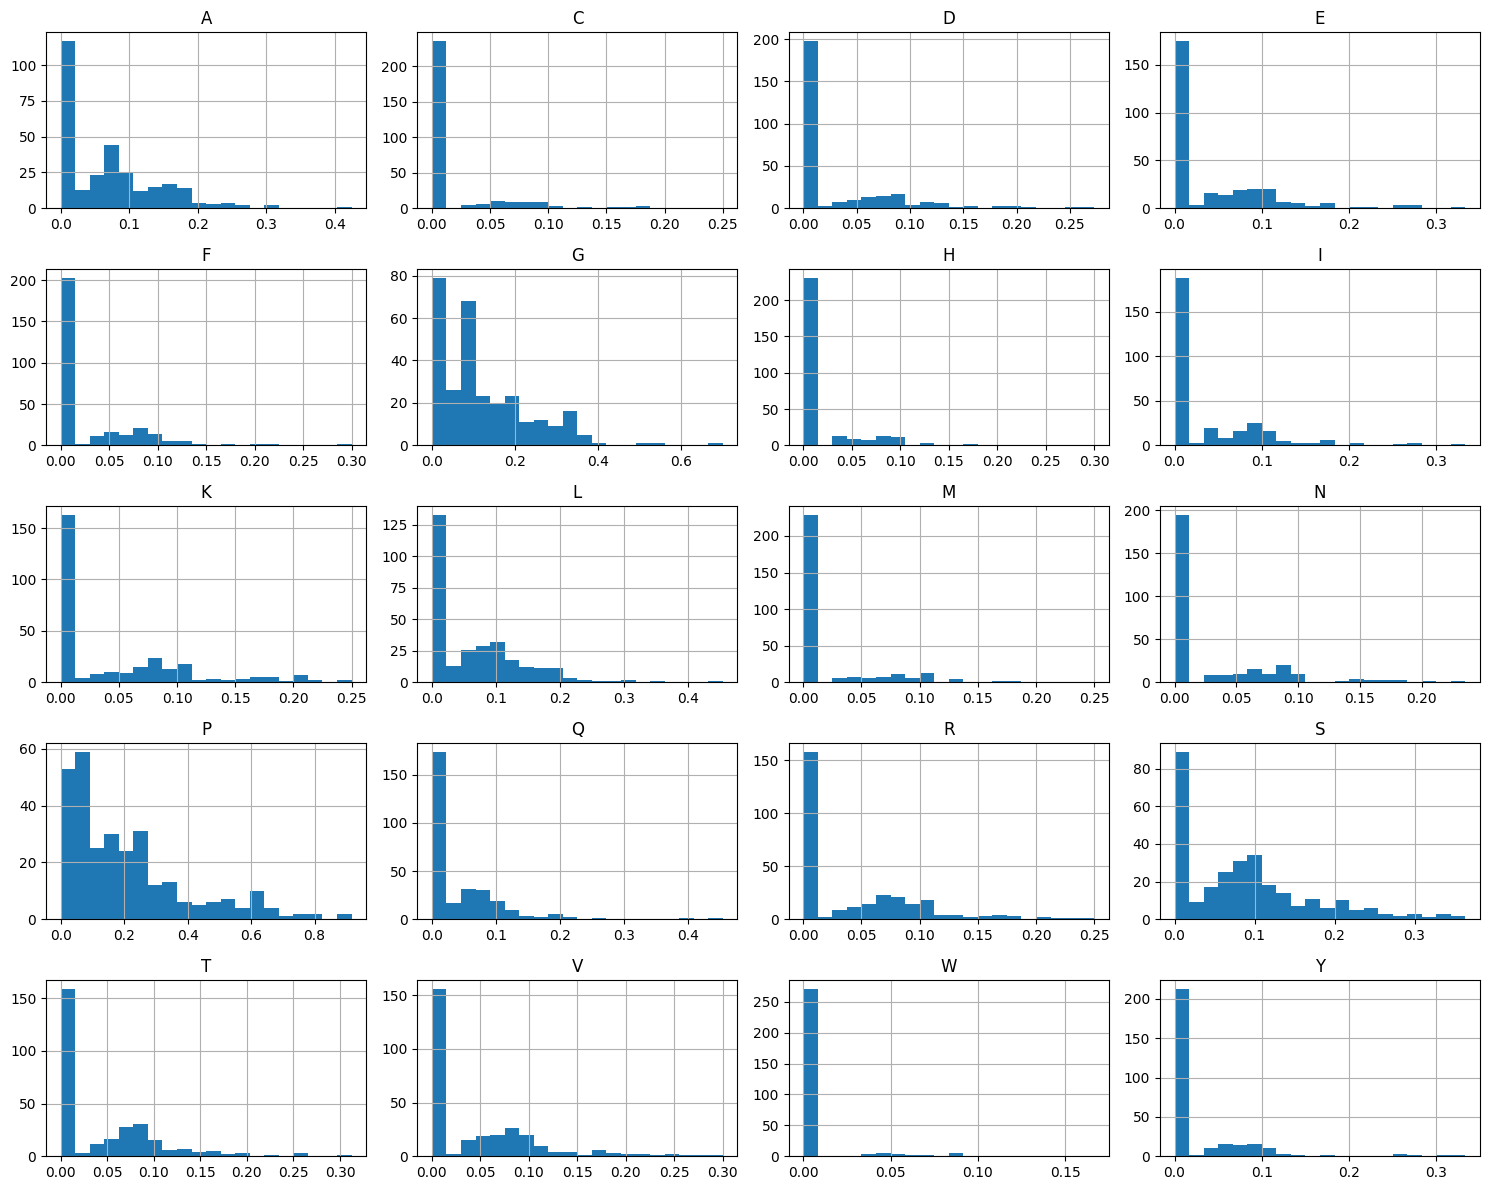

In [15]:
# Distribuição de Cada Descritor
aac_only.hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()

plt.show()

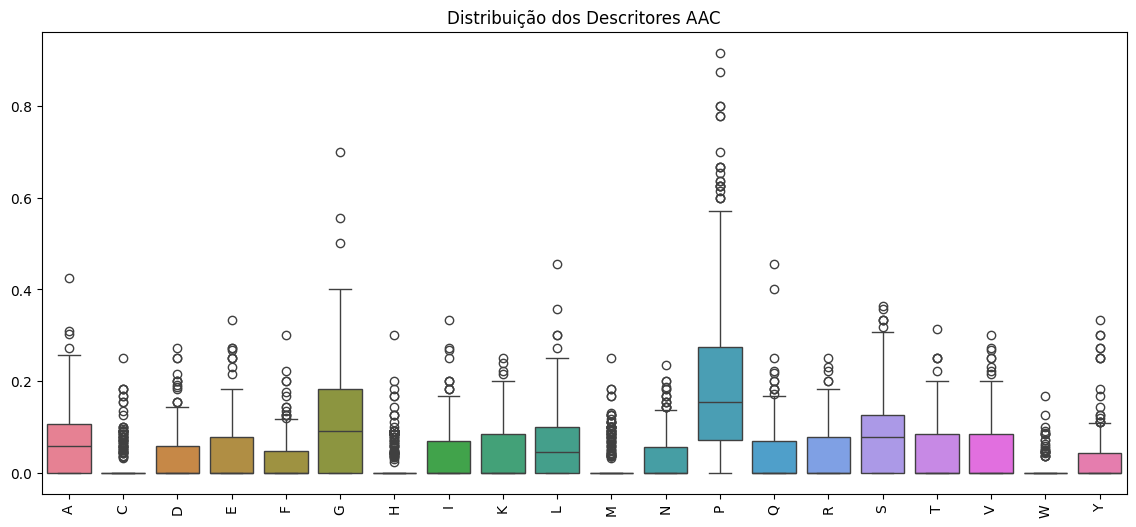

In [16]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=aac_only
)

plt.xticks(rotation=90)

plt.title("Distribuição dos Descritores AAC")

plt.show()

## Análise por Componentes Principais

A matriz AAC possui vinte atributos.

Embora esse número seja relativamente pequeno, é interessante investigar se os peptídeos apresentam agrupamentos naturais.

Para isso será utilizada a técnica de PCA (Principal Component Analysis), que projeta os dados em um espaço bidimensional preservando a maior parte possível da variabilidade.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

X = scaler.fit_transform(aac_only)

pca_aac = PCA(n_components=2)

X_pca = pca_aac.fit_transform(X)

print(pca_aac.explained_variance_ratio_)

[0.11563917 0.07579846]


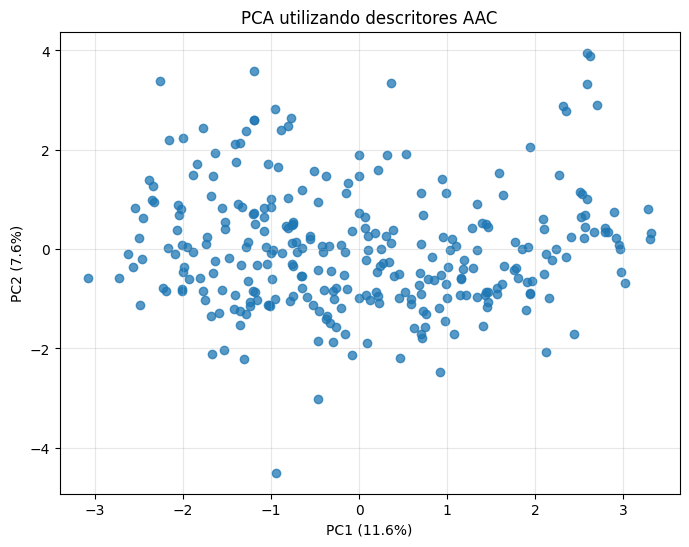

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.75
)

plt.title("PCA utilizando descritores AAC")

plt.xlabel(
    f"PC1 ({100*pca_aac.explained_variance_ratio_[0]:.1f}%)"
)

plt.ylabel(
    f"PC2 ({100*pca_aac.explained_variance_ratio_[1]:.1f}%)"
)

plt.grid(alpha=0.3)

plt.show()

In [ ]:
# Salvar o objeto PCA
import pickle

with open("../data/processed/pca_aac.pkl", "wb") as f:
    pickle.dump(pca_aac, f)


In [20]:
#Correlação do Docking com os Descritores AAC
corr_target = (
    aac_df
    .corr(numeric_only=True)["best_docking_score"]
    .drop("best_docking_score")
    .sort_values()
)

corr_target

Y   -0.344462
F   -0.290279
W   -0.256384
H   -0.209273
Q   -0.139204
R   -0.132075
G   -0.069810
P   -0.023589
S   -0.004468
C   -0.001742
M    0.038755
A    0.040736
T    0.074968
N    0.083413
L    0.125414
I    0.145110
V    0.163345
E    0.178062
D    0.188432
K    0.227608
Name: best_docking_score, dtype: float64

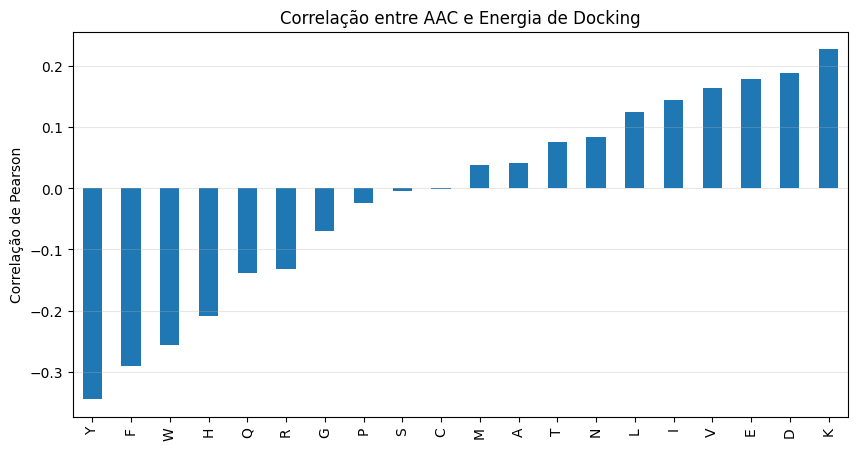

In [21]:
# Aqui já é possível identificar quais aminoácidos parecem influenciar mais a energia de docking.
# Correlação inversa!! O interesse é a energia de ligação negativa!
plt.figure(figsize=(10,5))

corr_target.plot(
    kind="bar"
)

plt.title(
    "Correlação entre AAC e Energia de Docking"
)

plt.ylabel("Correlação de Pearson")

plt.grid(axis="y",alpha=0.3)

plt.show()

In [22]:
aac_df.to_csv(
    "../data/processed/aac_features.csv",
    index=False
)

print("Dataset AAC salvo com sucesso.")

Dataset AAC salvo com sucesso.


## Conclusões

Neste notebook foi implementado manualmente o descritor **AAC (Amino Acid Composition)**, primeiro método de representação utilizado pelo framework SAGAPEP.

Cada sequência de aminoácidos foi transformada em um vetor de vinte atributos correspondentes às frequências relativas dos aminoácidos naturais, produzindo uma matriz de características adequada para algoritmos clássicos de Aprendizado de Máquina.

Além da implementação do algoritmo, foram realizadas análises estatísticas e visuais da matriz AAC, incluindo validação da codificação, distribuição dos atributos, correlação entre descritores e projeção por PCA.

Os resultados mostraram que o descritor AAC captura a composição global das sequências e fornece uma representação numérica consistente. Entretanto, por desconsiderar a ordem dos aminoácidos, ele possui capacidade limitada para representar padrões estruturais mais complexos. Essa limitação motiva a utilização de descritores mais sofisticados, como **AAL**, **CKSNAP** e **CKSAAGP**, que serão implementados nos próximos notebooks.

# Interpretação Biológica dos Descritores AAC

Até este ponto do notebook, o descritor AAC foi analisado apenas do ponto de vista estatístico.

Entretanto, cada atributo da matriz AAC representa um aminoácido específico, e cada aminoácido possui propriedades físico-químicas distintas, como:

- hidrofobicidade;
- carga elétrica;
- polaridade;
- aromaticidade;
- flexibilidade estrutural.

Assim, além de identificar quais descritores apresentam maior correlação com a energia de docking, é possível interpretar biologicamente esses resultados.

Essa análise permite compreender quais características químicas parecem favorecer ou desfavorecer a interação entre os peptídeos e a proteína Spike.

In [23]:
# ============================================================
# Propriedades físico-químicas dos aminoácidos
# ============================================================

aa_properties = pd.DataFrame({

    "Aminoacido":[
        "A","C","D","E","F",
        "G","H","I","K","L",
        "M","N","P","Q","R",
        "S","T","V","W","Y"
    ],

    "Nome":[
        "Alanina",
        "Cisteína",
        "Aspartato",
        "Glutamato",
        "Fenilalanina",
        "Glicina",
        "Histidina",
        "Isoleucina",
        "Lisina",
        "Leucina",
        "Metionina",
        "Asparagina",
        "Prolina",
        "Glutamina",
        "Arginina",
        "Serina",
        "Treonina",
        "Valina",
        "Triptofano",
        "Tirosina"
    ],

    "Carga":[
        "Neutra",
        "Neutra",
        "Negativa",
        "Negativa",
        "Neutra",
        "Neutra",
        "Positiva",
        "Neutra",
        "Positiva",
        "Neutra",
        "Neutra",
        "Neutra",
        "Neutra",
        "Neutra",
        "Positiva",
        "Neutra",
        "Neutra",
        "Neutra",
        "Neutra",
        "Neutra"
    ],

    "Polaridade":[
        "Apolar",
        "Polar",
        "Polar",
        "Polar",
        "Apolar",
        "Apolar",
        "Polar",
        "Apolar",
        "Polar",
        "Apolar",
        "Apolar",
        "Polar",
        "Apolar",
        "Polar",
        "Polar",
        "Polar",
        "Polar",
        "Apolar",
        "Apolar",
        "Polar"
    ],

    "Hidrofobicidade":[
        1.8,
        2.5,
        -3.5,
        -3.5,
        2.8,
        -0.4,
        -3.2,
        4.5,
        -3.9,
        3.8,
        1.9,
        -3.5,
        -1.6,
        -3.5,
        -4.5,
        -0.8,
        -0.7,
        4.2,
        -0.9,
        -1.3
    ]

})

aa_properties

,Aminoacido,Nome,Carga,Polaridade,Hidrofobicidade
0,A,Alanina,Neutra,Apolar,1.8
1,C,Cisteína,Neutra,Polar,2.5
2,D,Aspartato,Negativa,Polar,-3.5
3,E,Glutamato,Negativa,Polar,-3.5
4,F,Fenilalanina,Neutra,Apolar,2.8
5,G,Glicina,Neutra,Apolar,-0.4
6,H,Histidina,Positiva,Polar,-3.2
7,I,Isoleucina,Neutra,Apolar,4.5
8,K,Lisina,Positiva,Polar,-3.9
9,L,Leucina,Neutra,Apolar,3.8


In [24]:
# ============================================================
# Correlação AAC x Docking
# ============================================================

corr_target = (
    aac_df
    .corr(numeric_only=True)["best_docking_score"]
    .drop("best_docking_score")
)

corr_df = (
    corr_target
    .rename("Correlacao")
    .reset_index()
)

corr_df.columns=["Aminoacido","Correlacao"]

corr_df

,Aminoacido,Correlacao
0,A,0.040736
1,C,-0.001742
2,D,0.188432
3,E,0.178062
4,F,-0.290279
5,G,-0.069810
6,H,-0.209273
7,I,0.145110
8,K,0.227608
9,L,0.125414


In [25]:
interpretacao = aa_properties.merge(
    corr_df,
    on="Aminoacido"
)

interpretacao.sort_values(
    by="Correlacao",
    ascending=False
)

,Aminoacido,Nome,Carga,Polaridade,Hidrofobicidade,Correlacao
8,K,Lisina,Positiva,Polar,-3.9,0.227608
2,D,Aspartato,Negativa,Polar,-3.5,0.188432
3,E,Glutamato,Negativa,Polar,-3.5,0.178062
17,V,Valina,Neutra,Apolar,4.2,0.163345
7,I,Isoleucina,Neutra,Apolar,4.5,0.145110
9,L,Leucina,Neutra,Apolar,3.8,0.125414
11,N,Asparagina,Neutra,Polar,-3.5,0.083413
16,T,Treonina,Neutra,Polar,-0.7,0.074968
0,A,Alanina,Neutra,Apolar,1.8,0.040736
10,M,Metionina,Neutra,Apolar,1.9,0.038755


In [26]:
# ============================================================
# Grupo bioquímico dos aminoácidos
# ============================================================

# ============================================================
# Classificação bioquímica dos aminoácidos
# ============================================================

grupo = {
    "A": "Alifático",
    "V": "Alifático",
    "L": "Alifático",
    "I": "Alifático",
    "M": "Alifático",
    "F": "Aromático",
    "W": "Aromático",
    "Y": "Aromático",
    "S": "Polar",
    "T": "Polar",
    "N": "Polar",
    "Q": "Polar",
    "C": "Polar",
    "K": "Básico",
    "R": "Básico",
    "H": "Básico",
    "D": "Ácido",
    "E": "Ácido",
    "G": "Especial",
    "P": "Especial"
}

interpretacao["Grupo"] = (
    interpretacao["Aminoacido"]
    .map(grupo)
)

In [27]:
interpretacao.head()

,Aminoacido,Nome,Carga,Polaridade,Hidrofobicidade,Correlacao,Grupo
0,A,Alanina,Neutra,Apolar,1.8,0.040736,Alifático
1,C,Cisteína,Neutra,Polar,2.5,-0.001742,Polar
2,D,Aspartato,Negativa,Polar,-3.5,0.188432,Ácido
3,E,Glutamato,Negativa,Polar,-3.5,0.178062,Ácido
4,F,Fenilalanina,Neutra,Apolar,2.8,-0.290279,Aromático


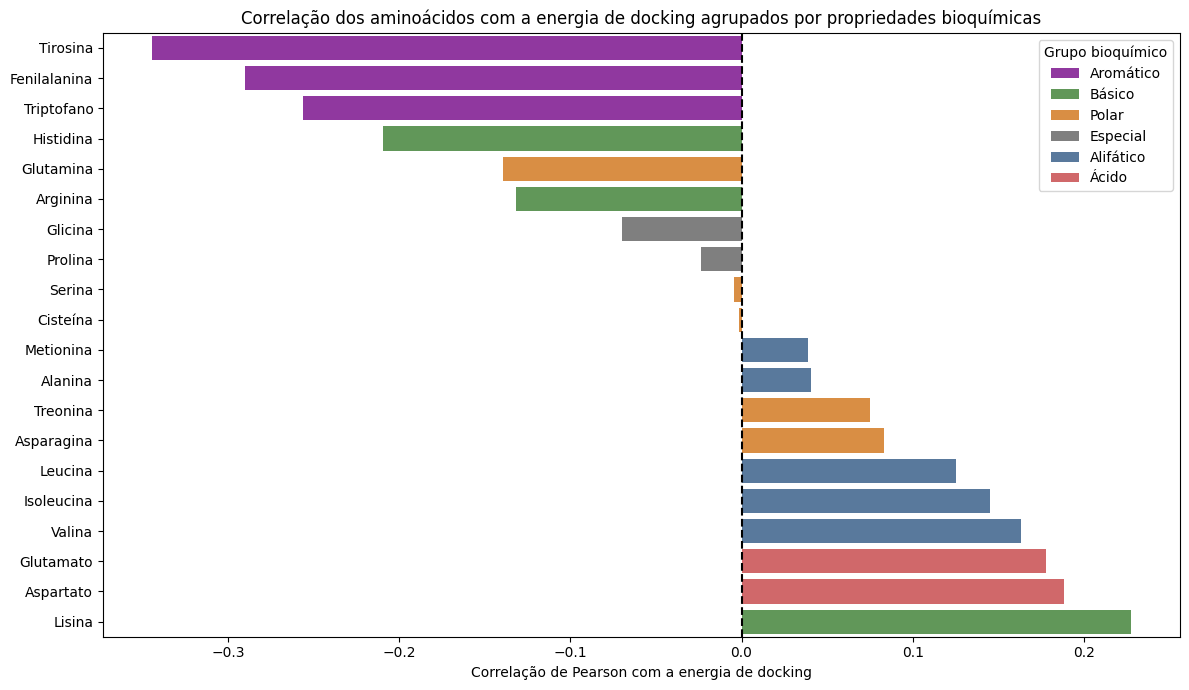

In [28]:
palette = {
    "Alifático": "#4E79A7",
    "Aromático": "#9C27B0",
    "Polar": "#F28E2B",
    "Básico": "#59A14F",
    "Ácido": "#E15759",
    "Especial": "#7F7F7F"
}

plt.figure(figsize=(12,7))

sns.barplot(
    data=interpretacao.sort_values("Correlacao"),
    x="Correlacao",
    y="Nome",
    hue="Grupo",
    dodge=False,
    palette=palette
)

plt.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Correlação de Pearson com a energia de docking")
plt.ylabel("")
plt.title("Correlação dos aminoácidos com a energia de docking agrupados por propriedades bioquímicas")

plt.legend(
    title="Grupo bioquímico",
    loc="upper right"
)

plt.tight_layout()

plt.show()

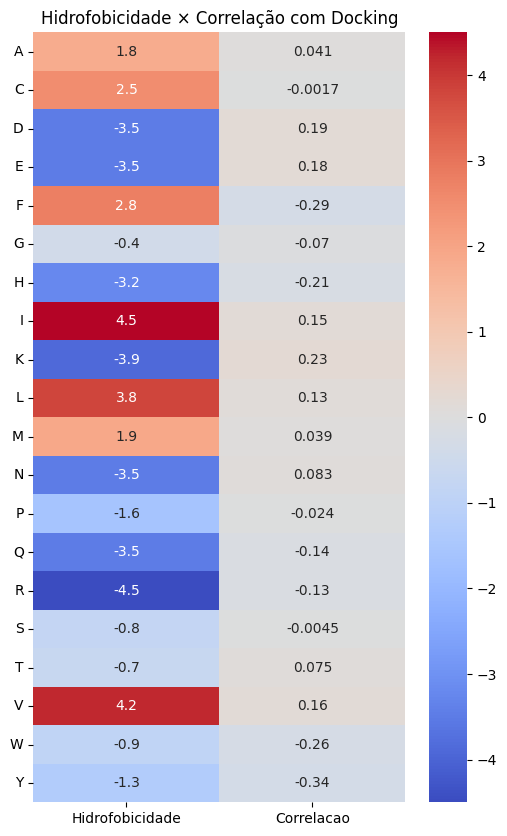

In [29]:
plt.figure(figsize=(6,10))

sns.heatmap(

    interpretacao[
        ["Hidrofobicidade","Correlacao"]
    ],

    annot=True,

    cmap="coolwarm",

    center=0

)

plt.yticks(

    np.arange(len(interpretacao))+0.5,

    interpretacao["Aminoacido"],

    rotation=0

)

plt.title("Hidrofobicidade × Correlação com Docking")

plt.show()

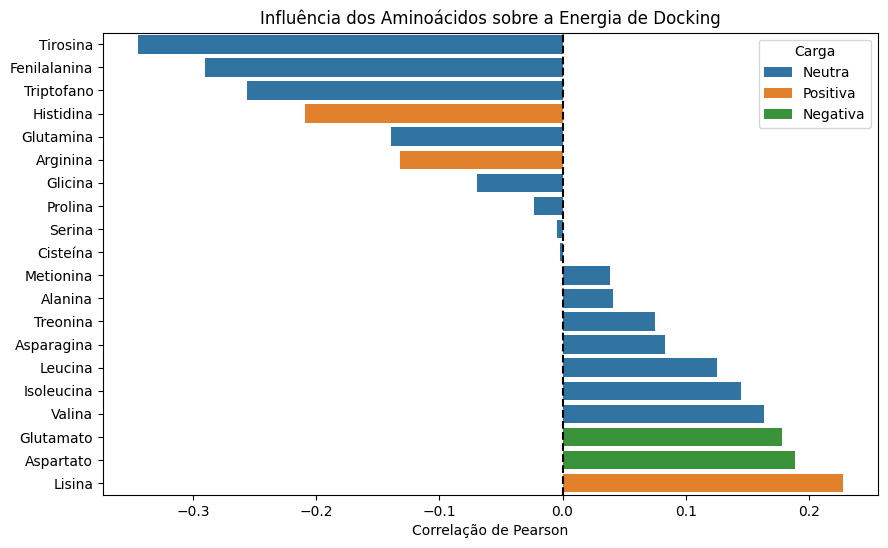

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=interpretacao.sort_values("Correlacao"),

    x="Correlacao",

    y="Nome",

    hue="Carga",

    dodge=False

)

plt.axvline(

    0,

    color="black",

    linestyle="--"

)

plt.title(

    "Influência dos Aminoácidos sobre a Energia de Docking"

)

plt.xlabel(

    "Correlação de Pearson"

)

plt.ylabel("")

plt.legend(title="Carga")

plt.show()

In [31]:
interpretacao.groupby(
    "Carga"
)["Correlacao"].mean()

Carga
Negativa    0.183247
Neutra     -0.030547
Positiva   -0.037913
Name: Correlacao, dtype: float64

In [32]:
interpretacao.groupby(
    "Polaridade"
)["Correlacao"].mean()

Polaridade
Apolar   -0.014078
Polar    -0.007158
Name: Correlacao, dtype: float64

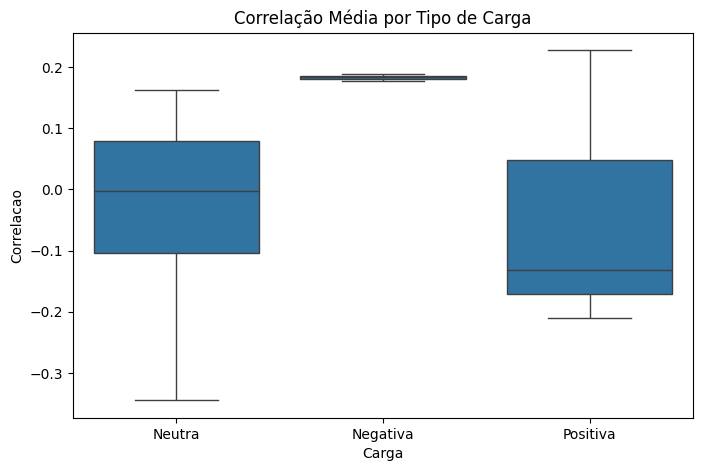

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(

    data=interpretacao,

    x="Carga",

    y="Correlacao"

)

plt.title("Correlação Média por Tipo de Carga")

plt.show()

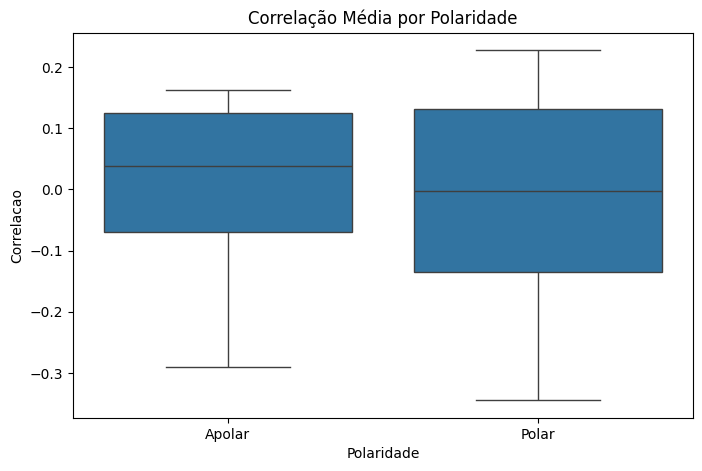

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(

    data=interpretacao,

    x="Polaridade",

    y="Correlacao"

)

plt.title("Correlação Média por Polaridade")

plt.show()

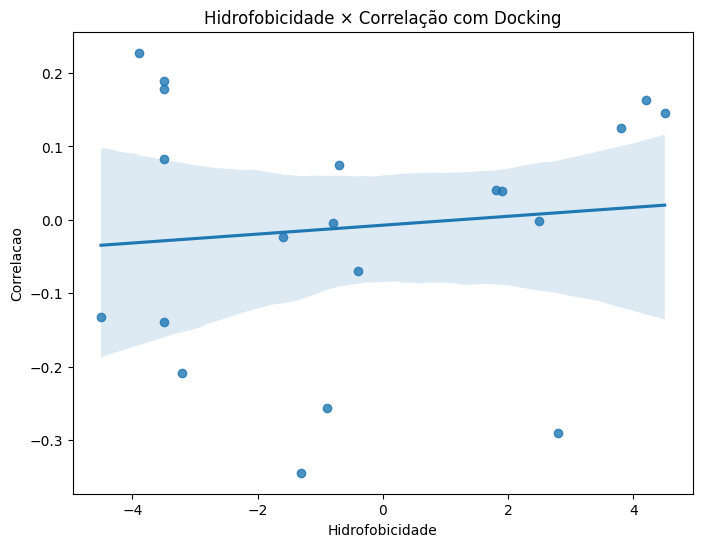

In [35]:
plt.figure(figsize=(8,6))

sns.regplot(

    data=interpretacao,

    x="Hidrofobicidade",

    y="Correlacao"

)

plt.title(

    "Hidrofobicidade × Correlação com Docking"

)

plt.show()

In [36]:
interpretacao.sort_values(

    "Correlacao",

    ascending=False

).round(3)

,Aminoacido,Nome,Carga,Polaridade,Hidrofobicidade,Correlacao,Grupo
8,K,Lisina,Positiva,Polar,-3.9,0.228,Básico
2,D,Aspartato,Negativa,Polar,-3.5,0.188,Ácido
3,E,Glutamato,Negativa,Polar,-3.5,0.178,Ácido
17,V,Valina,Neutra,Apolar,4.2,0.163,Alifático
7,I,Isoleucina,Neutra,Apolar,4.5,0.145,Alifático
9,L,Leucina,Neutra,Apolar,3.8,0.125,Alifático
11,N,Asparagina,Neutra,Polar,-3.5,0.083,Polar
16,T,Treonina,Neutra,Polar,-0.7,0.075,Polar
0,A,Alanina,Neutra,Apolar,1.8,0.041,Alifático
10,M,Metionina,Neutra,Apolar,1.9,0.039,Alifático


## Interpretação dos Resultados

A análise biológica dos descritores AAC permite identificar tendências interessantes entre as propriedades físico-químicas dos aminoácidos e sua associação com a energia de docking.

Ao agrupar os aminoácidos por carga elétrica, polaridade e hidrofobicidade, observa-se que determinados grupos apresentam correlação mais intensa com a variável resposta, sugerindo que a afinidade molecular não depende apenas da frequência individual de cada resíduo, mas também de suas propriedades químicas.

Entretanto, deve-se ressaltar que o descritor AAC considera apenas a composição global da sequência, ignorando completamente a posição dos aminoácidos.

Assim, dois peptídeos contendo exatamente os mesmos aminoácidos, porém em ordens diferentes, produzirão vetores AAC idênticos.

Essa limitação explica por que o AAC, embora simples e eficiente, normalmente apresenta desempenho inferior a descritores que incorporam informações estruturais, como AAL, CKSNAP e CKSAAGP.

Essa observação justifica a implementação desses descritores nos próximos notebooks e reforça a importância da engenharia de atributos em problemas de Bioinformática e Mineração de Dados.